In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder

In [3]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

builder = ModelDatasetBuilder(db_path)

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=False,
    lags=None,
    target_horizon=None,
    include_volumes=True,
    dropna=False
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value
datetime,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,1,31.77,4091.8,1819.6
2020-01-01 01:00:00,52,12,2020-01-01,2,31.57,4021.3,1826.2
2020-01-01 02:00:00,72,12,2020-01-01,3,31.28,3975.7,1836.8
2020-01-01 03:00:00,92,12,2020-01-01,4,30.72,3993.6,1841.5
2020-01-01 04:00:00,112,12,2020-01-01,5,30.27,4041.5,1798.0


In [4]:
# ============================================================
# 4. CREATE TEMPORAL SERIES AND EXOG VARIABLES
# ============================================================

df_model = df[
    [
        "price_value",
        "buy_volume_value",
        "sell_volume_value"
    ]
].asfreq("h").dropna()

ts = df_model["price_value"]

exog = df_model[
    [
        "buy_volume_value",
        "sell_volume_value"
    ]
]

print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing price:", ts.isna().sum())
print("Missing exog:")
print(exog.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

Length: (8761,)
Duplicates: 0
Missing price: 0
Missing exog:
buy_volume_value     0
sell_volume_value    0
dtype: int64
Start: 2020-01-01 00:00:00
End: 2020-12-31 00:00:00


In [5]:
# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

ts_model = ts["2020-01-01":"2020-12-31"]
exog_model = exog["2020-01-01":"2020-12-31"]

train = ts_model["2020-01-01":"2020-11-30 23:00:00"]
test = ts_model["2020-12-01":"2020-12-07 23:00:00"]

exog_train = exog_model.loc[train.index]
exog_test = exog_model.loc[test.index]

print("Train:", train.shape)
print("Test:", test.shape)
print("Exog train:", exog_train.shape)
print("Exog test:", exog_test.shape)

Train: (8040,)
Test: (168,)
Exog train: (8040, 2)
Exog test: (168, 2)


In [6]:
# ============================================================
# 6. ARIMA ROLLING ONE-STEP FORECAST
# ============================================================

arima_history = list(train)
arima_predictions = []

for t in range(len(test)):
    model = ARIMA(arima_history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    arima_predictions.append(yhat)

    arima_history.append(test.iloc[t])

arima_pred_series = pd.Series(arima_predictions, index=test.index)

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

In [8]:
# ============================================================
# 7. SARIMAX ROLLING ONE-STEP FORECAST
# ============================================================

sarimax_history_y = list(train)
sarimax_history_exog = exog_train.copy()

sarimax_predictions = []

for t in range(len(test)):
    model = SARIMAX(
        sarimax_history_y,
        exog=sarimax_history_exog,
        order=(3, 0, 3),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    yhat = model_fit.forecast(
        steps=1,
        exog=exog_test.iloc[[t]]
    ).iloc[0]

    sarimax_predictions.append(yhat)

    sarimax_history_y.append(test.iloc[t])
    sarimax_history_exog = pd.concat(
        [sarimax_history_exog, exog_test.iloc[[t]]]
    )

sarimax_pred_series = pd.Series(sarimax_predictions, index=test.index)

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

Ejecution was working almost 17 minutes.

In [9]:
# ============================================================
# 8. COMPARE RESULTS
# ============================================================

def evaluate_model(y_true, y_pred):
    return {
        "MedAE": median_absolute_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }
    
results = pd.DataFrame({
    "ARIMA": evaluate_model(test, arima_pred_series),
    "SARIMAX_volumes": evaluate_model(test, sarimax_pred_series)
}).T

results

,MedAE,MAE,RMSE,R2
ARIMA,0.644217,0.878556,1.166275,0.871335
SARIMAX_volumes,0.494518,0.762909,1.048965,0.895917


In [10]:
# ============================================================
# 9. EXTREME PRICE PERFORMANCE
# ============================================================

def evaluate_model_on_mask(y_true, y_pred, mask):
    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]

    return {
        "n_obs": len(y_true_masked),
        "MedAE": median_absolute_error(y_true_masked, y_pred_masked),
        "MAE": mean_absolute_error(y_true_masked, y_pred_masked),
        "RMSE": np.sqrt(mean_squared_error(y_true_masked, y_pred_masked)),
        "R2": r2_score(y_true_masked, y_pred_masked) if len(y_true_masked) > 1 else np.nan
    }


# Thresholds computed on the test real prices
p10 = test.quantile(0.10)
p90 = test.quantile(0.90)

high_price_mask = test > p90
low_price_mask = test < p10
normal_price_mask = (test >= p10) & (test <= p90)

extreme_results = pd.concat({
    "High prices > P90": pd.DataFrame({
        "ARIMA": evaluate_model_on_mask(test, arima_pred_series, high_price_mask),
        "SARIMAX_volumes": evaluate_model_on_mask(test, sarimax_pred_series, high_price_mask)
    }).T,

    "Low prices < P10": pd.DataFrame({
        "ARIMA": evaluate_model_on_mask(test, arima_pred_series, low_price_mask),
        "SARIMAX_volumes": evaluate_model_on_mask(test, sarimax_pred_series, low_price_mask)
    }).T,

    "Normal prices P10-P90": pd.DataFrame({
        "ARIMA": evaluate_model_on_mask(test, arima_pred_series, normal_price_mask),
        "SARIMAX_volumes": evaluate_model_on_mask(test, sarimax_pred_series, normal_price_mask)
    }).T
})

extreme_results

n_obs     MedAE       MAE      RMSE  \
High prices > P90     ARIMA             17.0  0.866557  0.968877  1.112524   
                      SARIMAX_volumes   17.0  0.831769  0.950927  1.081361   
Low prices < P10      ARIMA             16.0  1.268390  1.428554  1.611207   
                      SARIMAX_volumes   16.0  1.091040  1.168302  1.335134   
Normal prices P10-P90 ARIMA            135.0  0.526348  0.801998  1.108674   
                      SARIMAX_volumes  135.0  0.423806  0.691186  1.005374   

                                             R2  
High prices > P90     ARIMA           -9.767099  
                      SARIMAX_volumes -9.172349  
Low prices < P10      ARIMA           -0.254245  
                      SARIMAX_volumes  0.138749  
Normal prices P10-P90 ARIMA            0.757913  
                      SARIMAX_volumes  0.800924

In [11]:
# ============================================================
# 10. SUDDEN PRICE CHANGE PERFORMANCE
# ============================================================

# Absolute hourly price change in the test set
test_price_delta = test.diff().abs()

# Threshold for strong changes, using P90 of absolute changes
delta_p90 = test_price_delta.quantile(0.90)

strong_change_mask = test_price_delta > delta_p90
normal_change_mask = test_price_delta <= delta_p90

change_results = pd.concat({
    "Strong changes |delta| > P90": pd.DataFrame({
        "ARIMA": evaluate_model_on_mask(test, arima_pred_series, strong_change_mask),
        "SARIMAX_volumes": evaluate_model_on_mask(test, sarimax_pred_series, strong_change_mask)
    }).T,

    "Normal changes |delta| <= P90": pd.DataFrame({
        "ARIMA": evaluate_model_on_mask(test, arima_pred_series, normal_change_mask),
        "SARIMAX_volumes": evaluate_model_on_mask(test, sarimax_pred_series, normal_change_mask)
    }).T
})

change_results

n_obs     MedAE       MAE  \
Strong changes |delta| > P90  ARIMA             17.0  2.353649  2.481896   
                              SARIMAX_volumes   17.0  2.191323  2.221281   
Normal changes |delta| <= P90 ARIMA            150.0  0.543275  0.697615   
                              SARIMAX_volumes  150.0  0.435340  0.600704   

                                                   RMSE        R2  
Strong changes |delta| > P90  ARIMA            2.595867  0.338558  
                              SARIMAX_volumes  2.343595  0.460872  
Normal changes |delta| <= P90 ARIMA            0.869391  0.925265  
                              SARIMAX_volumes  0.780567  0.939756

In [12]:
# ============================================================
# 11. DIRECTIONAL ACCURACY
# ============================================================

def directional_accuracy(y_true, y_pred, mask=None):
    true_delta = y_true.diff()
    pred_delta = y_pred.diff()

    valid_mask = true_delta.notna() & pred_delta.notna()

    if mask is not None:
        valid_mask = valid_mask & mask

    true_direction = np.sign(true_delta[valid_mask])
    pred_direction = np.sign(pred_delta[valid_mask])

    return (true_direction == pred_direction).mean()


direction_results = pd.DataFrame({
    "Directional Accuracy": {
        "ARIMA_global": directional_accuracy(test, arima_pred_series),
        "SARIMAX_global": directional_accuracy(test, sarimax_pred_series),
        "ARIMA_strong_changes": directional_accuracy(test, arima_pred_series, strong_change_mask),
        "SARIMAX_strong_changes": directional_accuracy(test, sarimax_pred_series, strong_change_mask),
        "ARIMA_normal_changes": directional_accuracy(test, arima_pred_series, normal_change_mask),
        "SARIMAX_normal_changes": directional_accuracy(test, sarimax_pred_series, normal_change_mask),
    }
})

direction_results

,Directional Accuracy
ARIMA_global,0.664671
SARIMAX_global,0.724551
ARIMA_strong_changes,0.823529
SARIMAX_strong_changes,0.823529
ARIMA_normal_changes,0.646667
SARIMAX_normal_changes,0.713333


In [14]:
# ============================================================
# 12. PRICE CHANGE MAGNITUDE ERROR
# ============================================================

def evaluate_delta_error(y_true, y_pred, mask=None):
    true_delta = y_true.diff()
    pred_delta = y_pred.diff()

    valid_mask = true_delta.notna() & pred_delta.notna()

    if mask is not None:
        valid_mask = valid_mask & mask

    delta_error = true_delta[valid_mask] - pred_delta[valid_mask]

    return {
        "n_obs": valid_mask.sum(),
        "Delta_MedAE": np.median(np.abs(delta_error)),
        "Delta_MAE": np.mean(np.abs(delta_error)),
        "Delta_RMSE": np.sqrt(np.mean(delta_error ** 2)),
        "Mean_real_abs_delta": np.mean(np.abs(true_delta[valid_mask])),
        "Mean_pred_abs_delta": np.mean(np.abs(pred_delta[valid_mask]))
    }


delta_results = pd.concat({
    "Global delta error": pd.DataFrame({
        "ARIMA": evaluate_delta_error(test, arima_pred_series),
        "SARIMAX_volumes": evaluate_delta_error(test, sarimax_pred_series)
    }).T,

    "Strong changes delta error": pd.DataFrame({
        "ARIMA": evaluate_delta_error(test, arima_pred_series, strong_change_mask),
        "SARIMAX_volumes": evaluate_delta_error(test, sarimax_pred_series, strong_change_mask)
    }).T,

    "Normal changes delta error": pd.DataFrame({
        "ARIMA": evaluate_delta_error(test, arima_pred_series, normal_change_mask),
        "SARIMAX_volumes": evaluate_delta_error(test, sarimax_pred_series, normal_change_mask)
    }).T
})

delta_results

n_obs  Delta_MedAE  Delta_MAE  \
Global delta error         ARIMA            167.0     0.501316   0.731115   
                           SARIMAX_volumes  167.0     0.429016   0.675481   
Strong changes delta error ARIMA             17.0     1.648311   1.695692   
                           SARIMAX_volumes   17.0     1.230629   1.590620   
Normal changes delta error ARIMA            150.0     0.398030   0.621797   
                           SARIMAX_volumes  150.0     0.402352   0.571766   

                                            Delta_RMSE  Mean_real_abs_delta  \
Global delta error         ARIMA              1.043111             0.768503   
                           SARIMAX_volumes    1.029388             0.768503   
Strong changes delta error ARIMA              1.899203             2.778235   
                           SARIMAX_volumes    1.886300             2.778235   
Normal changes delta error ARIMA              0.895883             0.540733   
                           SARIMAX_volumes    0.881180             0.540733   

                                            Mean_pred_abs_delta  
Global delta error         ARIMA                       0.673945  
                           SARIMAX_volumes             0.680352  
Strong changes delta error ARIMA                       1.756029  
                           SARIMAX_volumes             1.968579  
Normal changes delta error ARIMA                       0.551309  
                           SARIMAX_volumes             0.534353

In [15]:
# ============================================================
# 13. SUMMARY OF KEY DIAGNOSTIC METRICS
# ============================================================

summary_diagnostics = pd.DataFrame({
    "Global_MedAE": {
        "ARIMA": results.loc["ARIMA", "MedAE"],
        "SARIMAX_volumes": results.loc["SARIMAX_volumes", "MedAE"]
    },
    "Global_MAE": {
        "ARIMA": results.loc["ARIMA", "MAE"],
        "SARIMAX_volumes": results.loc["SARIMAX_volumes", "MAE"]
    },
    "StrongChange_MAE": {
        "ARIMA": change_results.loc[("Strong changes |delta| > P90", "ARIMA"), "MAE"],
        "SARIMAX_volumes": change_results.loc[("Strong changes |delta| > P90", "SARIMAX_volumes"), "MAE"]
    },
    "StrongChange_Delta_MAE": {
        "ARIMA": delta_results.loc[("Strong changes delta error", "ARIMA"), "Delta_MAE"],
        "SARIMAX_volumes": delta_results.loc[("Strong changes delta error", "SARIMAX_volumes"), "Delta_MAE"]
    },
    "StrongChange_RealAbsDelta": {
        "ARIMA": delta_results.loc[("Strong changes delta error", "ARIMA"), "Mean_real_abs_delta"],
        "SARIMAX_volumes": delta_results.loc[("Strong changes delta error", "SARIMAX_volumes"), "Mean_real_abs_delta"]
    },
    "StrongChange_PredAbsDelta": {
        "ARIMA": delta_results.loc[("Strong changes delta error", "ARIMA"), "Mean_pred_abs_delta"],
        "SARIMAX_volumes": delta_results.loc[("Strong changes delta error", "SARIMAX_volumes"), "Mean_pred_abs_delta"]
    }
})

summary_diagnostics

,Global_MedAE,Global_MAE,StrongChange_MAE,StrongChange_Delta_MAE,StrongChange_RealAbsDelta,StrongChange_PredAbsDelta
ARIMA,0.644217,0.878556,2.481896,1.695692,2.778235,1.756029
SARIMAX_volumes,0.494518,0.762909,2.221281,1.590620,2.778235,1.968579


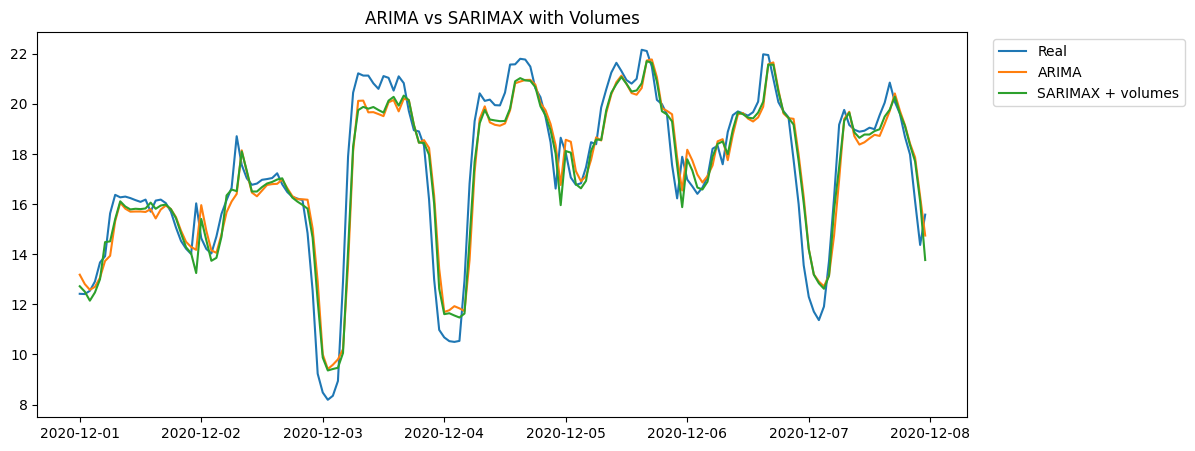

In [17]:
# ============================================================
# 14. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")
plt.plot(test.index, sarimax_pred_series, label="SARIMAX + volumes")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("ARIMA vs SARIMAX with Volumes")
plt.show()

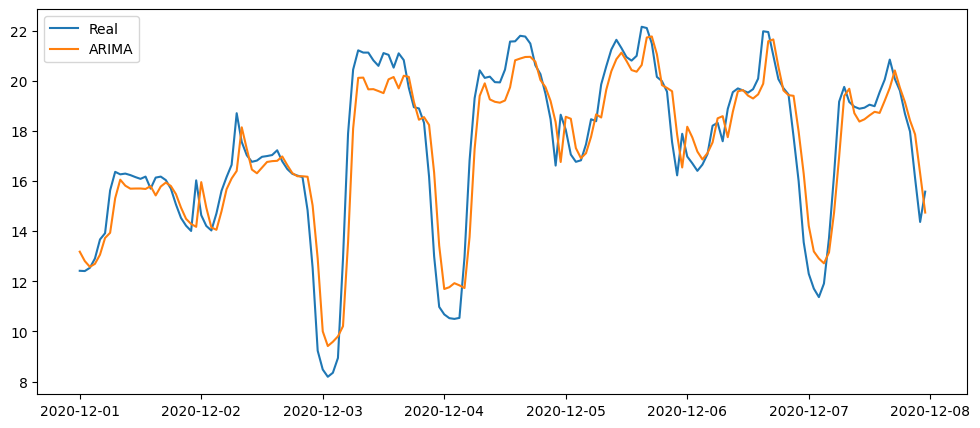

In [19]:
# ============================================================
# 15. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")

plt.legend()
plt.show()

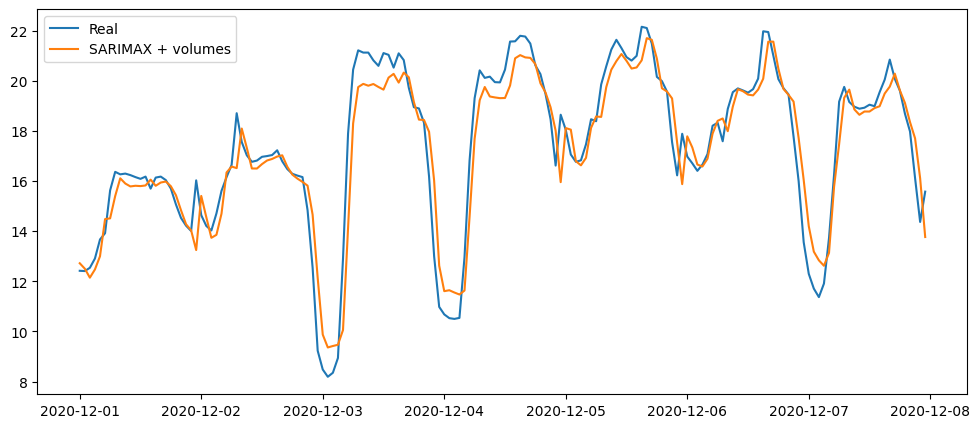

In [20]:
# ============================================================
# 16. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, sarimax_pred_series, label="SARIMAX + volumes")

plt.legend()
plt.show()